# 🩺 01 - Exploratory Data Analysis (EDA)
## AMEEMAW: AI Mamma-Echography Educator & Empathetic Mentor for Awareness & Wellness

**Author:** Shira Amina Ortiz Olivares 🐧  
**Date:** December 2025  
**Dataset:** Breast Ultrasound Images (BUSI)

---

### 🐧 Hey there! Welcome to our EDA journey!

In this notebook, we're going to get to know our dataset really well. Think of it like a first date with data — we want to understand what we're working with before we start building models!

**What we'll discover:**
1. 📂 Load and peek at the BUSI dataset structure
2. ⚖️ Check out class distribution (spoiler: it's imbalanced!)
3. 📐 Explore image properties like dimensions and intensity
4. 👀 Visualize sample images from each class
5. 🎭 Examine segmentation masks
6. 📏 Analyze lesion sizes
7. 💾 Save our findings for the next notebook

Let's dive in! 🏊‍♂️

---

## 1. 🔧 Environment Setup

🐧 First things first — let's make sure our environment is ready to go. This cell works whether you're running locally or in Colab!

In [1]:
# ============================================
# ENVIRONMENT SETUP
# Detects Colab vs local and sets up accordingly
# ============================================

import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🐧 Hey! Running in Google Colab!")
    print("📦 Installing extra packages...\n")
    !pip install -q grad-cam anthropic
    !mkdir -p /content/reports/figures /content/data/processed
    print("\n✅ Colab setup complete!")
    print("\n💡 REMINDER: Upload Dataset_BUSI_with_GT folder using the 📁 sidebar!")
else:
    print("💻 Running locally — no additional setup needed!")

🐧 Hey! Running in Google Colab!
📦 Installing extra packages...


✅ Colab setup complete!

💡 REMINDER: Upload Dataset_BUSI_with_GT folder using the 📁 sidebar!


## 2. 📚 Imports

🐧 Time to bring in our toolbox!

In [2]:
# ============================================
# IMPORTS - Our data science toolbox 🧰
# ============================================

import os
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("✅ All imports successful!")
print("🐧 We're locked and loaded!")

✅ All imports successful!
🐧 We're locked and loaded!


## 3. 📂 Path Configuration

🐧 Let's tell Python where to find our data.

💡 **Colab users:** Upload `Dataset_BUSI_with_GT` folder to `/content/`
> * Tip: upload in ZIP then just unzip after. It's faster!

In [3]:
# ============================================
# PATH CONFIGURATION
# Works for both Colab and local!
# ============================================

if IN_COLAB:
    !unzip -q /content/Dataset_BUSI_with_GT.zip -d /content/                        # uncomment this is you uploaded a ZIP version
    DATA_DIR = Path("/content/Dataset_BUSI_with_GT")
    PROJECT_ROOT = Path("/content")
else:
    PROJECT_ROOT = Path.cwd().parent
    DATA_DIR = PROJECT_ROOT / "data" / "raw" / "Dataset_BUSI_with_GT"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("📂 Path Configuration")
print("=" * 40)
print(f"Data Directory: {DATA_DIR}")
print(f"Figures Directory: {FIGURES_DIR}")

if DATA_DIR.exists():
    print(f"\n✅ Data directory found!")
    print(f"📁 Contents: {os.listdir(DATA_DIR)}")
else:
    print(f"\n❌ Data directory NOT found!")
    print("🐧 Please upload/extract the BUSI dataset first!")

📂 Path Configuration
Data Directory: /content/Dataset_BUSI_with_GT
Figures Directory: /content/reports/figures

✅ Data directory found!
📁 Contents: ['normal', 'malignant', 'benign']


---

## 4. 📊 Load the Dataset

🐧 Now for the fun part — let's load our data!

💡 The BUSI dataset has 3 folders (`normal/`, `benign/`, `malignant/`) with images and masks.

In [4]:
def load_dataset_info(data_dir):
    """
    Load dataset info into a DataFrame.
    Parses folder structure and links images to masks.
    """
    records = []
    classes = ['normal', 'benign', 'malignant']

    for class_name in classes:
        class_dir = data_dir / class_name
        if not class_dir.exists():
            print(f"⚠️ Warning: {class_dir} not found")
            continue

        for file_path in class_dir.glob("*.png"):
            filename = file_path.name
            if '_mask' in filename:  # Skip masks, we'll link them
                continue

            base_name = file_path.stem
            mask_path = class_dir / f"{base_name}_mask.png"
            has_mask = mask_path.exists()
            mask_count = len(list(class_dir.glob(f"{base_name}_mask*.png")))

            records.append({
                'image_path': str(file_path),
                'mask_path': str(mask_path) if has_mask else None,
                'class': class_name,
                'has_mask': has_mask,
                'mask_count': mask_count,
                'filename': filename
            })

    df = pd.DataFrame(records)
    df['class_encoded'] = df['class'].map({'normal': 0, 'benign': 1, 'malignant': 2})
    return df

# Load it!
print("🐧 Loading dataset...")
df = load_dataset_info(DATA_DIR)
print(f"✅ Loaded {len(df)} images!\n")
df.head()

🐧 Loading dataset...
✅ Loaded 780 images!



,image_path,mask_path,class,has_mask,mask_count,filename,class_encoded
0,/content/Dataset_BUSI_with_GT/normal/normal (3...,/content/Dataset_BUSI_with_GT/normal/normal (3...,normal,True,1,normal (31).png,0
1,/content/Dataset_BUSI_with_GT/normal/normal (1...,/content/Dataset_BUSI_with_GT/normal/normal (1...,normal,True,1,normal (100).png,0
2,/content/Dataset_BUSI_with_GT/normal/normal (8...,/content/Dataset_BUSI_with_GT/normal/normal (8...,normal,True,1,normal (82).png,0
3,/content/Dataset_BUSI_with_GT/normal/normal (8...,/content/Dataset_BUSI_with_GT/normal/normal (8...,normal,True,1,normal (88).png,0
4,/content/Dataset_BUSI_with_GT/normal/normal (7...,/content/Dataset_BUSI_with_GT/normal/normal (7...,normal,True,1,normal (70).png,0


### 🐧💡 Quick Data Check

In [5]:
print("🐧 DATASET OVERVIEW")
print("=" * 50)
print(f"📊 Total images: {len(df)}")
print(f"🎭 Images with masks: {df['has_mask'].sum()}")
print(f"🚫 Images without masks: {(~df['has_mask']).sum()}")

🐧 DATASET OVERVIEW
📊 Total images: 780
🎭 Images with masks: 780
🚫 Images without masks: 0


---

## 5. ⚖️ Class Distribution Analysis

🐧 This is super important! Let's see how our classes are distributed.

💡 **Why it matters:** Imbalanced classes can trick our model into being lazy...

In [6]:
# Class counts and percentages
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

print("🐧 CLASS DISTRIBUTION")
print("=" * 35)
for cls in ['normal', 'benign', 'malignant']:
    print(f"{cls.capitalize():<12} {class_counts[cls]:>4} ({class_pct[cls]:.1f}%)")
print("-" * 35)
print(f"{'TOTAL':<12} {len(df):>4}")

🐧 CLASS DISTRIBUTION
Normal        133 (17.1%)
Benign        437 (56.0%)
Malignant     210 (26.9%)
-----------------------------------
TOTAL         780


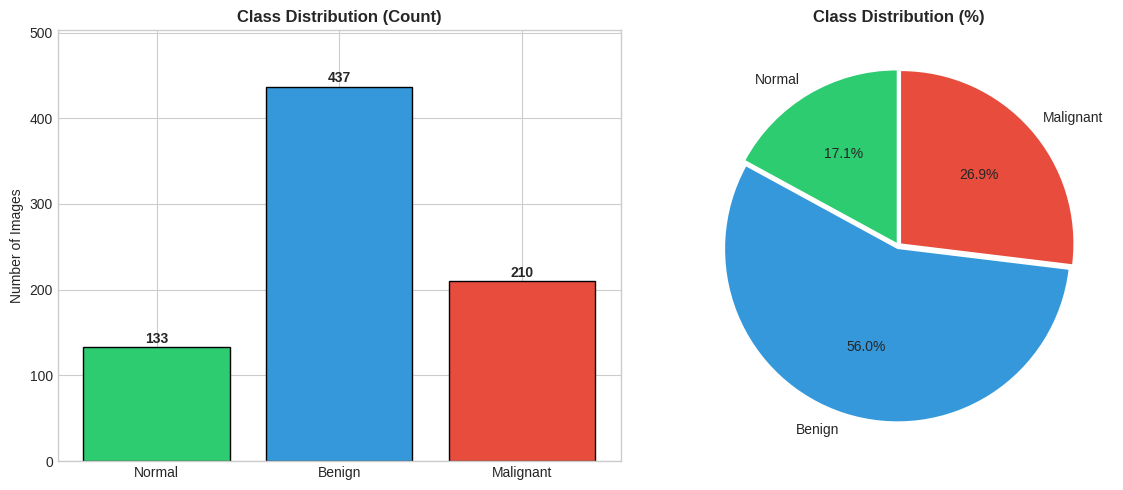

📊 Saved: class_distribution.png


In [7]:
# Visualization
colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green, Blue, Red

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
bars = axes[0].bar(['Normal', 'Benign', 'Malignant'],
                   [class_counts['normal'], class_counts['benign'], class_counts['malignant']],
                   color=colors, edgecolor='black')
for bar, count in zip(bars, [class_counts['normal'], class_counts['benign'], class_counts['malignant']]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylim(0, max(class_counts) * 1.15)

# Pie chart
axes[1].pie([class_counts['normal'], class_counts['benign'], class_counts['malignant']],
            labels=['Normal', 'Benign', 'Malignant'], colors=colors,
            autopct='%1.1f%%', startangle=90, explode=(0.02, 0.02, 0.02))
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: class_distribution.png")

### 🐧💡 Class Imbalance Alert!

Whoa! Our dataset is definitely **imbalanced**:
- **Benign** dominates (>50%)
- **Normal** is the minority (<20%)
- **Malignant** sits in the middle

This is common in medical data — people get ultrasounds when there's a concern!

**What this means for us:**
- ✅ MUST use stratified splits
- ✅ Consider class weights during training
- ✅ Use F1-score & AUC-ROC, not just accuracy
- ✅ May need augmentation for minority classes

In [8]:
# Quantify imbalance
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"📏 Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"   (Benign has {imbalance_ratio:.1f}x more samples than Normal)")

📏 Imbalance ratio: 3.29:1
   (Benign has 3.3x more samples than Normal)


---

## 6. 📐 Image Properties Analysis

🐧 Let's look at the actual image properties.

💡 We need to know dimensions for resizing and intensity for normalization.

In [9]:
def extract_image_properties(image_path):
    """Extract dimensions and intensity stats from an image."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return {
        'height': img.shape[0],
        'width': img.shape[1],
        'aspect_ratio': img.shape[1] / img.shape[0],
        'mean_intensity': np.mean(img),
        'std_intensity': np.std(img),
        'min_intensity': np.min(img),
        'max_intensity': np.max(img)
    }

print("🐧 Extracting image properties...")
props = [extract_image_properties(p) for p in df['image_path']]
props_df = pd.DataFrame([p for p in props if p])
df = pd.concat([df.reset_index(drop=True), props_df], axis=1)
print(f"✅ Done! Processed {len(props_df)} images")

🐧 Extracting image properties...
✅ Done! Processed 780 images


In [10]:
print("🐧 IMAGE DIMENSION STATISTICS")
print("=" * 50)
print(df[['height', 'width', 'aspect_ratio']].describe().round(2))

🐧 IMAGE DIMENSION STATISTICS
       height    width  aspect_ratio
count  780.00   780.00        780.00
mean   501.45   615.68          1.23
std     76.69   122.06          0.17
min    310.00   190.00          0.57
25%    465.00   554.00          1.17
50%    474.00   564.00          1.20
75%    574.00   713.50          1.32
max    719.00  1048.00          2.05


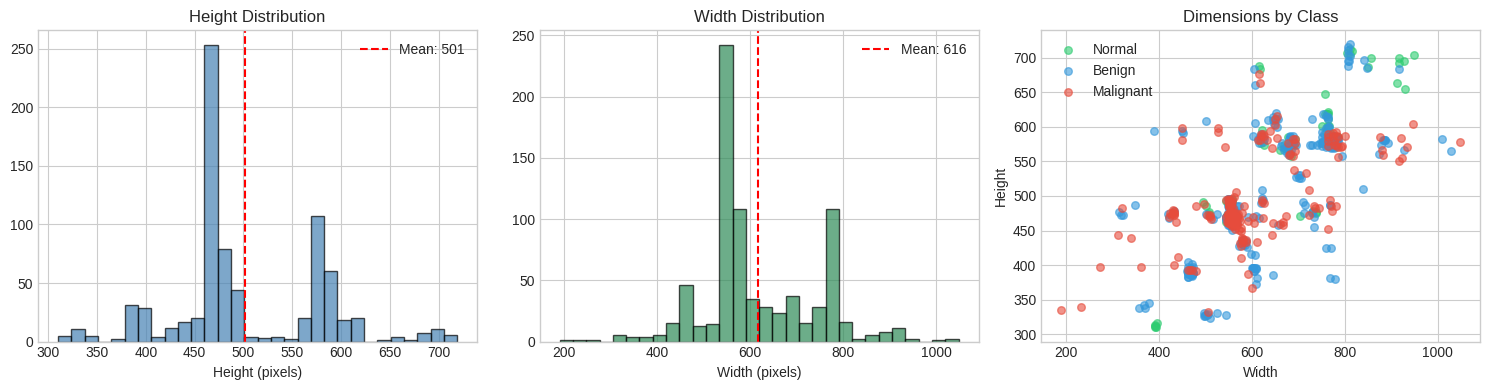

📊 Saved: image_dimensions.png


In [11]:
# Visualization: Dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['height'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['height'].mean(), color='red', linestyle='--', label=f'Mean: {df["height"].mean():.0f}')
axes[0].set_xlabel('Height (pixels)')
axes[0].set_title('Height Distribution')
axes[0].legend()

axes[1].hist(df['width'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[1].axvline(df['width'].mean(), color='red', linestyle='--', label=f'Mean: {df["width"].mean():.0f}')
axes[1].set_xlabel('Width (pixels)')
axes[1].set_title('Width Distribution')
axes[1].legend()

for cls, color in zip(['normal', 'benign', 'malignant'], colors):
    mask = df['class'] == cls
    axes[2].scatter(df.loc[mask, 'width'], df.loc[mask, 'height'],
                    c=color, label=cls.capitalize(), alpha=0.6, s=30)
axes[2].set_xlabel('Width')
axes[2].set_ylabel('Height')
axes[2].set_title('Dimensions by Class')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: image_dimensions.png")

### 🐧💡 Insight: Variable Image Sizes!

Our images vary quite a bit in size. This means:
1. **We'll resize** all images to 224x224 (standard for CNNs)
2. **Aspect ratios vary** — be careful about distortion
3. Consider padding vs. stretching strategies

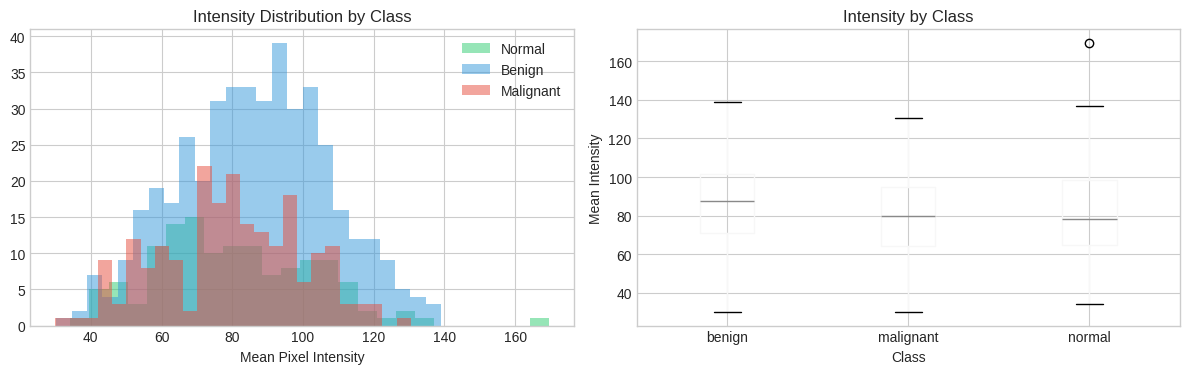

📊 Saved: intensity_distribution.png


In [12]:
# Intensity by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, color in zip(['normal', 'benign', 'malignant'], colors):
    data = df[df['class'] == cls]['mean_intensity']
    axes[0].hist(data, bins=25, color=color, alpha=0.5, label=cls.capitalize())
axes[0].set_xlabel('Mean Pixel Intensity')
axes[0].set_title('Intensity Distribution by Class')
axes[0].legend()

df.boxplot(column='mean_intensity', by='class', ax=axes[1])
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Mean Intensity')
axes[1].set_title('Intensity by Class')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'intensity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: intensity_distribution.png")

### 🐧💡 Insight: Intensity Patterns

The intensity distributions overlap a lot between classes. This tells us:
1. **Intensity alone won't work** for classification
2. **Texture and shape** will be more important
3. That's exactly why we need CNNs! 🧠

---

## 7. 👀 Sample Image Visualization

🐧 Let's actually LOOK at some images!

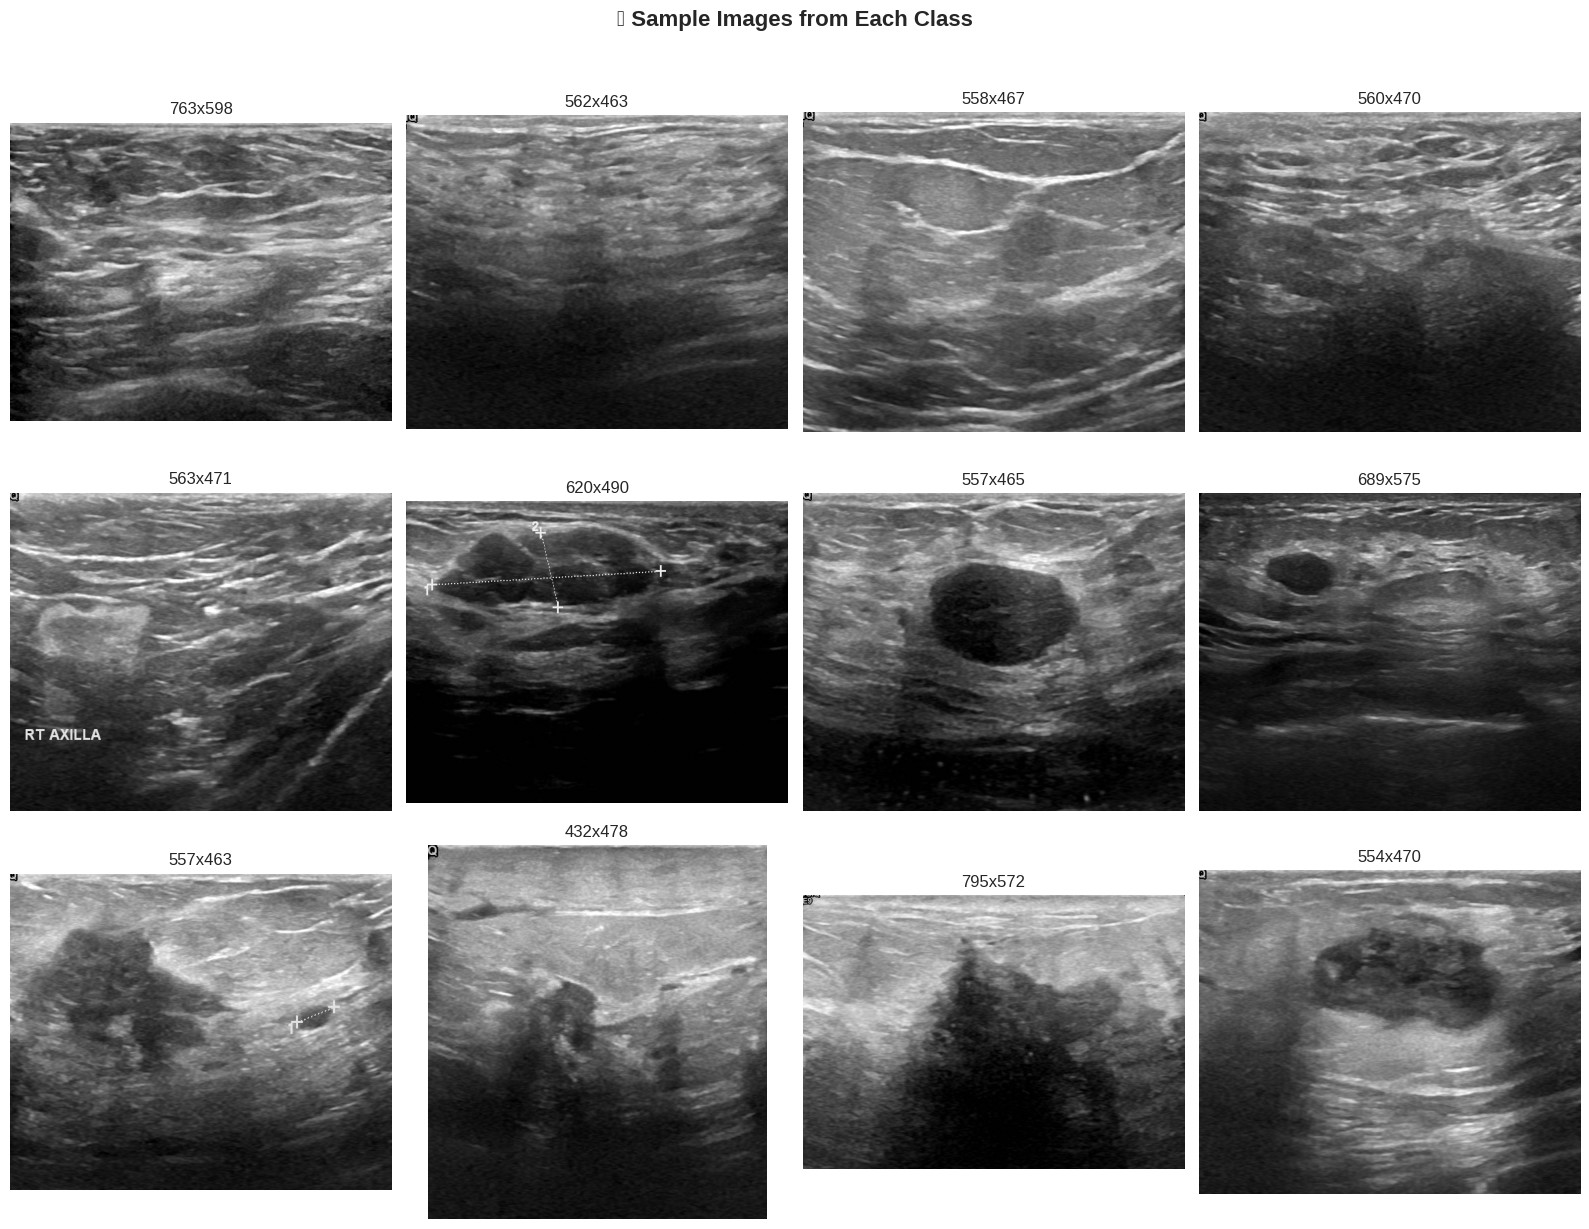

📊 Saved: sample_images.png


In [13]:
def display_samples(df, n=4, seed=42):
    """Display sample images from each class."""
    np.random.seed(seed)
    fig, axes = plt.subplots(3, n, figsize=(4*n, 12))

    for i, cls in enumerate(['normal', 'benign', 'malignant']):
        samples = df[df['class'] == cls].sample(n=n)
        for j, (_, row) in enumerate(samples.iterrows()):
            img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
            axes[i, j].imshow(img, cmap='gray')
            axes[i, j].axis('off')
            axes[i, j].set_title(f'{img.shape[1]}x{img.shape[0]}')
            if j == 0:
                axes[i, j].set_ylabel(cls.upper(), fontsize=14, fontweight='bold')

    plt.suptitle('🐧 Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

display_samples(df)
print("📊 Saved: sample_images.png")

### 🐧💡 Visual Observations

Notice how:
- **Normal** shows uniform, organized tissue
- **Benign** lesions often appear well-defined and oval
- **Malignant** may have irregular borders and heterogeneous texture

These are the patterns our CNN will learn! 🔬

---

## 8. 🎭 Segmentation Mask Analysis

🐧 BUSI includes masks showing where lesions are!

💡 Useful for radiomics features and Grad-CAM validation.

In [14]:
print("🐧 MASK AVAILABILITY BY CLASS")
print("=" * 40)
for cls in ['normal', 'benign', 'malignant']:
    class_df = df[df['class'] == cls]
    has_mask_count = class_df['has_mask'].sum()
    total = len(class_df)
    print(f"{cls.capitalize():<12} {has_mask_count:>3} mask files / {total} total")

print("\n💡 Normal mask files exist but are EMPTY (blank)!")
print("   Only Benign & Malignant have actual lesion regions marked. See images in the next cell.")

🐧 MASK AVAILABILITY BY CLASS
Normal       133 mask files / 133 total
Benign       437 mask files / 437 total
Malignant    210 mask files / 210 total

💡 Normal mask files exist but are EMPTY (blank)!
   Only Benign & Malignant have actual lesion regions marked. See images in the next cell.


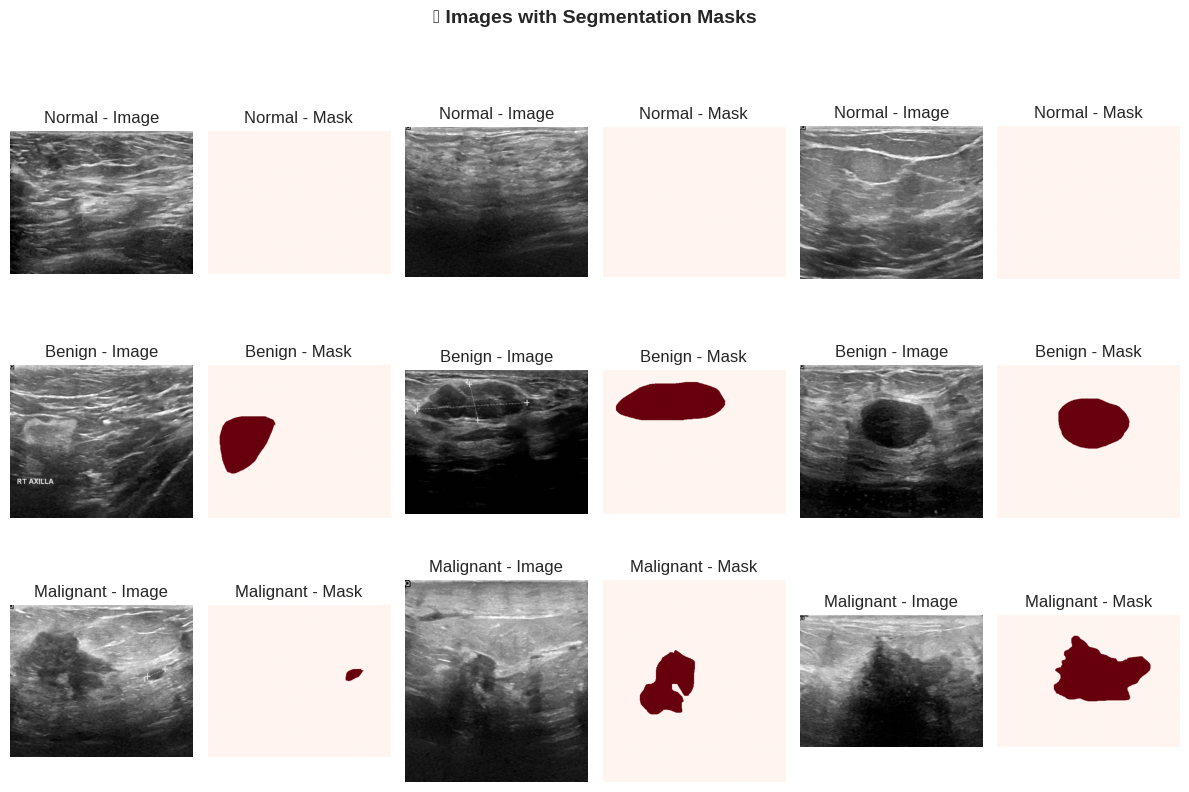

📊 Saved: images_with_masks.png


In [15]:
def display_with_masks(df, n=3, seed=42):
    """Display images with their masks side by side."""
    np.random.seed(seed)
    fig, axes = plt.subplots(3, n*2, figsize=(4*n, 8))

    for i, cls in enumerate(['normal', 'benign', 'malignant']):
        samples = df[(df['class'] == cls) & df['has_mask']].sample(n=n)
        for j, (_, row) in enumerate(samples.iterrows()):
            img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

            axes[i, j*2].imshow(img, cmap='gray')
            axes[i, j*2].axis('off')
            axes[i, j*2].set_title(f'{cls.capitalize()} - Image')

            axes[i, j*2+1].imshow(mask, cmap='Reds')
            axes[i, j*2+1].axis('off')
            axes[i, j*2+1].set_title(f'{cls.capitalize()} - Mask')

    plt.suptitle('🐧 Images with Segmentation Masks', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'images_with_masks.png', dpi=150, bbox_inches='tight')
    plt.show()

display_with_masks(df)
print("📊 Saved: images_with_masks.png")

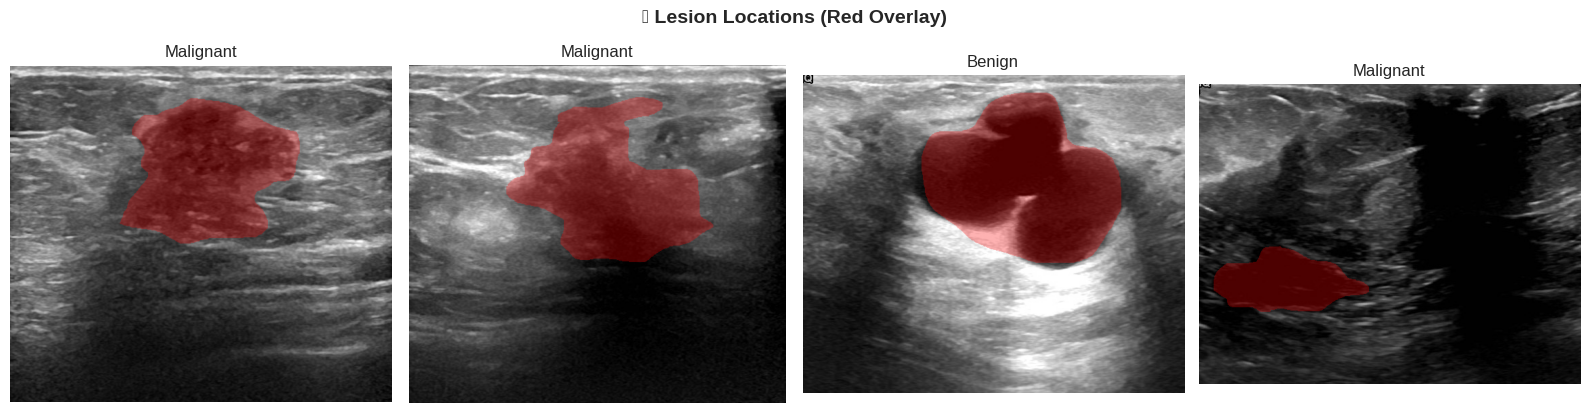

📊 Saved: mask_overlays.png


In [16]:
def display_overlay(df, n=4, seed=42):
    """Display images with red overlay on lesion."""
    np.random.seed(seed)
    mask_df = df[df['has_mask']].sample(n=n)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

    for j, (_, row) in enumerate(mask_df.iterrows()):
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

        overlay = img.copy()
        overlay[mask > 0] = [255, 0, 0]
        blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

        axes[j].imshow(blended)
        axes[j].axis('off')
        axes[j].set_title(row['class'].capitalize())

    plt.suptitle('🐧 Lesion Locations (Red Overlay)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'mask_overlays.png', dpi=150, bbox_inches='tight')
    plt.show()

display_overlay(df)
print("📊 Saved: mask_overlays.png")

---

## 9. 📏 Lesion Size Analysis

🐧 Let's measure lesion sizes from the masks!

In [17]:
def calc_lesion_props(row):
    """Calculate lesion area and ratio from mask."""
    if not row['has_mask'] or row['mask_path'] is None:
        return {'lesion_area': None, 'lesion_ratio': None}

    mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return {'lesion_area': None, 'lesion_ratio': None}

    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return {'lesion_area': 0, 'lesion_ratio': 0}

    area = cv2.contourArea(max(contours, key=cv2.contourArea))
    total = mask.shape[0] * mask.shape[1]
    return {'lesion_area': area, 'lesion_ratio': area / total * 100}

print("🐧 Calculating lesion sizes...")
lesion_props = df.apply(calc_lesion_props, axis=1, result_type='expand')
df = pd.concat([df, lesion_props], axis=1)
print("✅ Done!")
display(df.head())

🐧 Calculating lesion sizes...
✅ Done!


,image_path,mask_path,class,has_mask,mask_count,filename,class_encoded,height,width,aspect_ratio,mean_intensity,std_intensity,min_intensity,max_intensity,lesion_area,lesion_ratio
0,/content/Dataset_BUSI_with_GT/normal/normal (3...,/content/Dataset_BUSI_with_GT/normal/normal (3...,normal,True,1,normal (31).png,0,473,547,1.156448,88.956271,62.339838,0,255,0.0,0.0
1,/content/Dataset_BUSI_with_GT/normal/normal (1...,/content/Dataset_BUSI_with_GT/normal/normal (1...,normal,True,1,normal (100).png,0,574,690,1.202091,60.309478,33.816918,0,241,0.0,0.0
2,/content/Dataset_BUSI_with_GT/normal/normal (8...,/content/Dataset_BUSI_with_GT/normal/normal (8...,normal,True,1,normal (82).png,0,468,560,1.196581,86.678751,58.195398,0,255,0.0,0.0
3,/content/Dataset_BUSI_with_GT/normal/normal (8...,/content/Dataset_BUSI_with_GT/normal/normal (8...,normal,True,1,normal (88).png,0,463,560,1.209503,48.149360,43.660827,0,241,0.0,0.0
4,/content/Dataset_BUSI_with_GT/normal/normal (7...,/content/Dataset_BUSI_with_GT/normal/normal (7...,normal,True,1,normal (70).png,0,471,557,1.182590,87.893385,43.471589,0,255,0.0,0.0


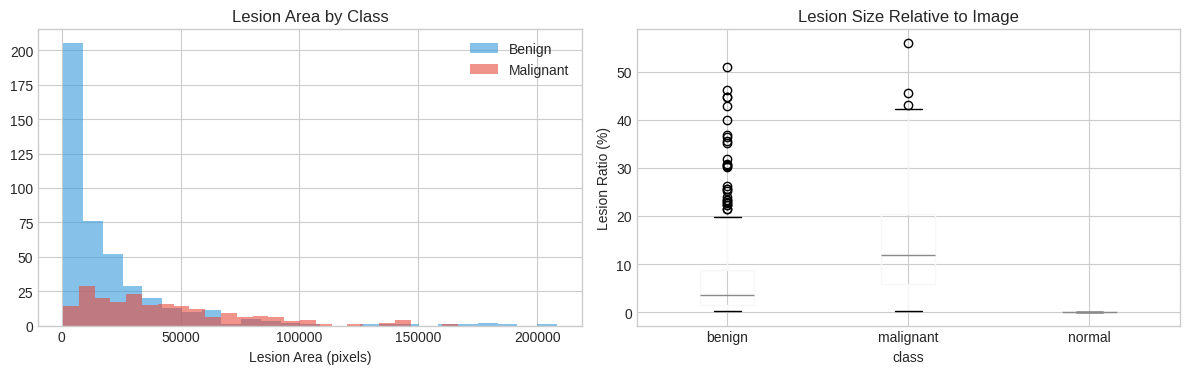

📊 Saved: lesion_sizes.png


In [18]:
# Visualize lesion sizes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mask_df = df[df['has_mask']]

for cls, color in zip(['benign', 'malignant'], ['#3498db', '#e74c3c']):
    data = mask_df[mask_df['class'] == cls]['lesion_area'].dropna()
    axes[0].hist(data, bins=25, color=color, alpha=0.6, label=cls.capitalize())
axes[0].set_xlabel('Lesion Area (pixels)')
axes[0].set_title('Lesion Area by Class')
axes[0].legend()

mask_df.boxplot(column='lesion_ratio', by='class', ax=axes[1])
axes[1].set_ylabel('Lesion Ratio (%)')
axes[1].set_title('Lesion Size Relative to Image')
plt.suptitle('')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lesion_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: lesion_sizes.png")

### 🐧💡 Insight: Overlapping Lesion Sizes

Benign and malignant lesions have **overlapping size distributions**. This means:
- Size alone won't distinguish them
- We need texture, shape, and spatial patterns
- CNNs to the rescue! 🦸

---

## 10. 💾 Save Processed Data

In [19]:
output_path = PROCESSED_DIR / 'image_metadata.csv'
df.to_csv(output_path, index=False)

print("🐧 DATA SAVED!")
print(f"📁 Location: {output_path}")
print(f"📐 Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")

if IN_COLAB:
    print("\n💡 Download this file and put it in your local data/processed/ folder!")

🐧 DATA SAVED!
📁 Location: /content/data/processed/image_metadata.csv
📐 Shape: (780, 16)
📋 Columns: ['image_path', 'mask_path', 'class', 'has_mask', 'mask_count', 'filename', 'class_encoded', 'height', 'width', 'aspect_ratio', 'mean_intensity', 'std_intensity', 'min_intensity', 'max_intensity', 'lesion_area', 'lesion_ratio']

💡 Download this file and put it in your local data/processed/ folder!


---

## 11. 📝 Summary

### 🐧 What We Learned!

| Metric | Value |
|--------|-------|
| Total Images | 780 |
| Normal | 133 (17%) |
| Benign | 437 (56%) |
| Malignant | 210 (27%) |
| Imbalance Ratio | ~3.3:1 |

### 💡 Key Takeaways

1. **Class imbalance** → Use stratified splits, class weights, F1/AUC
2. **Variable sizes** → Resize to 224x224
3. **Overlapping intensities** → Need CNNs for spatial patterns
4. **Quality masks** → Great for radiomics & Grad-CAM validation
5. **Overlapping lesion sizes** → Texture/shape more important than size

In [20]:
print("\n" + "="*55)
print("🐧✨ EDA COMPLETE! ✨🐧")
print("="*55)
print("\n📊 Figures saved:")
print("   • class_distribution.png")
print("   • image_dimensions.png")
print("   • intensity_distribution.png")
print("   • sample_images.png")
print("   • images_with_masks.png")
print("   • mask_overlays.png")
print("   • lesion_sizes.png")
print("\n💾 Data: image_metadata.csv")
print("\n🚀 NEXT: 02_feature_engineering.ipynb")


🐧✨ EDA COMPLETE! ✨🐧

📊 Figures saved:
   • class_distribution.png
   • image_dimensions.png
   • intensity_distribution.png
   • sample_images.png
   • images_with_masks.png
   • mask_overlays.png
   • lesion_sizes.png

💾 Data: image_metadata.csv

🚀 NEXT: 02_feature_engineering.ipynb


----
### End of Notebook
----